# HMS V14_1 — High-Consensus EEG Classification

**Changes from v12:**
- Uses `confident_train.csv` / `confident_test.csv` (pre-filtered data)
- Proper data augmentation via `data_aug` module:
  - Per-sample: Gaussian noise, amplitude scaling, time shift
  - Batch-level: MixUp (probabilistic), time masking, channel dropout
- No inline augmentation hacks
- Test evaluation at the end with `confident_test.csv`

In [1]:
import os, math, random, gc
from pathlib import Path
from typing import Callable, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast

import timm
from nnAudio.features import STFT
from sklearn.model_selection import StratifiedGroupKFold
from scipy.signal import butter, sosfiltfilt
import joblib

print(f"PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.10.0+cu128, CUDA: True
GPU: Tesla T4


# Data Augmentation

In [2]:
from __future__ import annotations

from typing import Callable, List, Tuple

import numpy as np
import torch


def _cfg_float(cfg, name: str, default: float) -> float:
    """Read float config values with a fallback.

    Parameters
    ----------
    cfg : object
        Configuration object with optional attribute ``name``.
    name : str
        Attribute name to read.
    default : float
        Fallback value when ``name`` is missing.

    Returns
    -------
    float
        Parsed float value.
    """
    return float(getattr(cfg, name, default))


def _cfg_int(cfg, name: str, default: int) -> int:
    """Read integer config values with a fallback.

    Parameters
    ----------
    cfg : object
        Configuration object with optional attribute ``name``.
    name : str
        Attribute name to read.
    default : int
        Fallback value when ``name`` is missing.

    Returns
    -------
    int
        Parsed integer value.
    """
    return int(getattr(cfg, name, default))


def _cfg_bool(cfg, name: str, default: bool) -> bool:
    """Read boolean config values with a fallback.

    Parameters
    ----------
    cfg : object
        Configuration object with optional attribute ``name``.
    name : str
        Attribute name to read.
    default : bool
        Fallback value when ``name`` is missing.

    Returns
    -------
    bool
        Parsed boolean value.
    """
    return bool(getattr(cfg, name, default))


def apply_time_shift(x: np.ndarray, shift: int) -> np.ndarray:
    """Apply zero-padded temporal shift to a multi-channel signal.

    Parameters
    ----------
    x : numpy.ndarray
        Input signal array of shape ``(channels, time)``.
    shift : int
        Signed temporal shift in samples. Positive values shift right.

    Returns
    -------
    numpy.ndarray
        Shifted signal array with the same shape as ``x``.
    """
    if shift == 0:
        return x
    out = np.zeros_like(x)
    if shift > 0:
        out[:, shift:] = x[:, :-shift]
    else:
        out[:, :shift] = x[:, -shift:]
    return out


def augment_sample_np(x: np.ndarray, cfg, target_sample_rate: int) -> np.ndarray:
    """Apply per-sample raw EEG augmentations in numpy space.

    Parameters
    ----------
    x : numpy.ndarray
        Input EEG sample of shape ``(channels, time)``.
    cfg : object
        Runtime configuration with augmentation ranges.
    target_sample_rate : int
        Sampling rate used to convert shift seconds to samples.

    Returns
    -------
    numpy.ndarray
        Augmented EEG sample with unchanged shape.
    """
    noise_std_min = _cfg_float(cfg, 'aug_noise_std_min', 0.0015)
    noise_std_max = _cfg_float(cfg, 'aug_noise_std_max', 0.0060)
    scale_min = _cfg_float(cfg, 'aug_scale_min', 0.93)
    scale_max = _cfg_float(cfg, 'aug_scale_max', 1.07)
    max_shift_seconds = _cfg_float(cfg, 'aug_max_shift_seconds', 0.25)

    if noise_std_max > 0:
        noise_std = np.random.uniform(noise_std_min, noise_std_max)
        x = x + np.random.normal(0.0, noise_std, size=x.shape).astype(np.float32)

    if scale_max > 0:
        scale = np.random.uniform(scale_min, scale_max)
        x = x * scale

    max_shift = max(0, int(round(max_shift_seconds * float(target_sample_rate))))
    if max_shift > 0:
        shift = np.random.randint(-max_shift, max_shift + 1)
        x = apply_time_shift(x, shift)

    return x.astype(np.float32)


def apply_mixup_batch(
    x: torch.Tensor,
    y: torch.Tensor,
    votes: torch.Tensor,
    cfg,
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """Apply MixUp to a training batch.

    Parameters
    ----------
    x : torch.Tensor
        Batch tensor of shape ``(batch, channels, time)``.
    y : torch.Tensor
        Soft label tensor of shape ``(batch, classes)``.
    votes : torch.Tensor
        Vote-count tensor of shape ``(batch,)``.
    cfg : object
        Runtime configuration containing MixUp settings.

    Returns
    -------
    tuple of torch.Tensor
        Mixed tensors ``(x, y, votes)`` with unchanged shapes.
    """
    use_mixup = _cfg_bool(cfg, 'use_mixup', True)
    mixup_prob = _cfg_float(cfg, 'mixup_prob', 0.60)
    mixup_alpha = _cfg_float(cfg, 'mixup_alpha', 0.40)

    bsz = int(x.shape[0])
    if not use_mixup or bsz < 2 or mixup_prob <= 0.0:
        return x, y, votes
    if np.random.rand() > mixup_prob:
        return x, y, votes

    alpha = max(mixup_alpha, 1e-6)
    lam_np = np.random.beta(alpha, alpha, size=bsz).astype(np.float32)
    perm = torch.randperm(bsz, device=x.device)
    lam = torch.tensor(lam_np, dtype=x.dtype, device=x.device)

    lam_x = lam.view(bsz, 1, 1)
    lam_y = lam.view(bsz, 1)

    x_mix = lam_x * x + (1.0 - lam_x) * x[perm]
    y_mix = lam_y * y + (1.0 - lam_y) * y[perm]

    votes_float = votes.to(dtype=x.dtype)
    votes_mix = lam * votes_float + (1.0 - lam) * votes_float[perm]
    votes_mix = votes_mix.to(dtype=votes.dtype)

    return x_mix, y_mix, votes_mix


def apply_time_mask_batch(x: torch.Tensor, cfg) -> torch.Tensor:
    """Apply random temporal masking to batch tensors.

    Parameters
    ----------
    x : torch.Tensor
        Batch tensor of shape ``(batch, channels, time)``.
    cfg : object
        Runtime configuration containing time-mask settings.

    Returns
    -------
    torch.Tensor
        Time-masked batch tensor with unchanged shape.
    """
    prob = _cfg_float(cfg, 'time_mask_prob', 0.35)
    frac_min = _cfg_float(cfg, 'time_mask_frac_min', 0.03)
    frac_max = _cfg_float(cfg, 'time_mask_frac_max', 0.10)

    if prob <= 0.0:
        return x

    bsz, _channels, seq_len = x.shape
    min_len = max(1, int(round(frac_min * seq_len)))
    max_len = max(min_len, int(round(frac_max * seq_len)))

    for i in range(bsz):
        if np.random.rand() > prob:
            continue
        span = np.random.randint(min_len, max_len + 1)
        if span >= seq_len:
            x[i, :, :] = 0
            continue
        start = np.random.randint(0, seq_len - span + 1)
        x[i, :, start:start + span] = 0
    return x


def apply_channel_dropout_batch(x: torch.Tensor, cfg) -> torch.Tensor:
    """Drop random channels in batch tensors.

    Parameters
    ----------
    x : torch.Tensor
        Batch tensor of shape ``(batch, channels, time)``.
    cfg : object
        Runtime configuration containing channel-drop settings.

    Returns
    -------
    torch.Tensor
        Channel-dropped batch tensor with unchanged shape.
    """
    prob = _cfg_float(cfg, 'channel_drop_prob', 0.25)
    max_drop = _cfg_int(cfg, 'channel_drop_max', 2)

    if prob <= 0.0 or max_drop <= 0:
        return x

    bsz, channels, _seq_len = x.shape
    max_drop = min(max_drop, channels)
    if max_drop <= 0:
        return x

    for i in range(bsz):
        if np.random.rand() > prob:
            continue
        n_drop = np.random.randint(1, max_drop + 1)
        drop_idx = np.random.choice(channels, size=n_drop, replace=False)
        x[i, drop_idx, :] = 0
    return x


def build_train_collate_fn(
    cfg,
) -> Callable[
    [List[Tuple[torch.Tensor, torch.Tensor, torch.Tensor]]],
    Tuple[torch.Tensor, torch.Tensor, torch.Tensor],
]:
    """Create a collate function with batch-level train augmentations.

    Parameters
    ----------
    cfg : object
        Runtime configuration with MixUp and masking settings.

    Returns
    -------
    callable
        Collate function for train DataLoader batches.
    """

    def collate_train(batch):
        """Collate and augment one train batch.

        Parameters
        ----------
        batch : list of tuple
            List of ``(x, y, votes)`` samples from the dataset.

        Returns
        -------
        tuple of torch.Tensor
            Augmented batch tensors ``(x, y, votes)``.
        """
        x_list, y_list, v_list = zip(*batch)
        x = torch.stack(x_list, dim=0).float()
        y = torch.stack(y_list, dim=0).float()
        votes = torch.stack(v_list, dim=0)

        x, y, votes = apply_mixup_batch(x, y, votes, cfg)
        x = apply_time_mask_batch(x, cfg)
        x = apply_channel_dropout_batch(x, cfg)
        return x, y, votes

    return collate_train


# Configuration

In [3]:
class CFG:
    seed = 42
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Classes
    num_classes = 6
    class_names = ["Seizure", "LPD", "GPD", "LRDA", "GRDA", "Other"]
    name2label = {v: k for k, v in enumerate(class_names)}

    # EEG
    eeg_sample_rate = 200
    eeg_duration = 50
    eeg_samples = eeg_sample_rate * eeg_duration  # 10000
    num_bipolar_channels = 16

    # Bandpass
    bandpass_low = 0.5
    bandpass_high = 20.0
    bandpass_order = 4

    # STFT
    n_fft = 512
    hop_length = 128
    zoom_duration = 10
    zoom_hop_length = 32
    freq_crop_hz = 20.0
    trainable_stft = True

    # Model
    backbone = "tf_efficientnetv2_b2"
    gru_hidden = 256
    gru_layers = 2
    dropout = 0.35

    # Training
    epochs = 20
    batch_size = 16
    use_amp = False
    max_grad_norm = 1.0
    num_workers = 4
    n_folds = 5
    run_folds = [0, 1, 2, 3, 4]

    # Learning rates
    lr_head = 3e-4
    lr_stft = 1e-4
    lr_backbone = 5e-5
    warmup_epochs = 1

    # Data
    use_soft_labels = True
    label_smoothing = 0.05

    # SpecAugment (in model)
    spec_freq_mask = 10
    spec_time_mask = 10
    spec_num_masks = 2

    # Per-sample augmentation (data_aug)
    aug_noise_std_min = 0.0015
    aug_noise_std_max = 0.006
    aug_scale_min = 0.93
    aug_scale_max = 1.07
    aug_max_shift_seconds = 0.25

    # Batch-level augmentation (data_aug)
    use_mixup = True
    mixup_prob = 0.60
    mixup_alpha = 0.40
    time_mask_prob = 0.35
    time_mask_frac_min = 0.03
    time_mask_frac_max = 0.10
    channel_drop_prob = 0.25
    channel_drop_max = 2

# Print summary
max_bin = int(CFG.freq_crop_hz / (CFG.eeg_sample_rate / CFG.n_fft)) + 1
wide_frames = (CFG.eeg_samples - CFG.n_fft) // CFG.hop_length + 1
print(f"STFT: n_fft={CFG.n_fft}, {max_bin} freq bins, {wide_frames} time frames")
print(f"Image: [3, {16 * max_bin}, {wide_frames}]")
print(f"Training: {CFG.epochs} epochs, batch={CFG.batch_size}, AMP={CFG.use_amp}")
print(f"LRs: head={CFG.lr_head}, stft={CFG.lr_stft}, backbone={CFG.lr_backbone}")
print(f"Augmentation: mixup_prob={CFG.mixup_prob}, mixup_alpha={CFG.mixup_alpha}")

STFT: n_fft=512, 52 freq bins, 75 time frames
Image: [3, 832, 75]
Training: 20 epochs, batch=16, AMP=False
LRs: head=0.0003, stft=0.0001, backbone=5e-05
Augmentation: mixup_prob=0.6, mixup_alpha=0.4


In [4]:
def set_seed(seed=CFG.seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed()

# Paths

In [5]:
project_root = Path.cwd()
BASE_PATH = project_root.parent.parent.parent / "data" / "data"

MODELS_DIR = project_root / "models"
RESULTS_DIR = project_root / "results"
PROCESSED_DIR = BASE_PATH / "processed" / "bipolar_eegs"
for d in [MODELS_DIR, RESULTS_DIR, PROCESSED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Data: {BASE_PATH} (exists={BASE_PATH.exists()})")
print(f"Processed EEGs: {PROCESSED_DIR}")

Data: /home/littl/data/data (exists=True)
Processed EEGs: /home/littl/data/data/processed/bipolar_eegs


# Load Data (confident_train.csv)

In [6]:
# Load pre-filtered confident train data
df = pd.read_csv(BASE_PATH / "confident_train.csv")
df["eeg_path"] = df["eeg_id"].apply(lambda x: str(BASE_PATH / "train_eegs" / f"{x}.parquet"))
df["class_name"] = df["expert_consensus"].copy()
df["class_label"] = df["expert_consensus"].map(CFG.name2label)

# Compute soft labels
vote_cols = ["seizure_vote", "lpd_vote", "gpd_vote", "lrda_vote", "grda_vote", "other_vote"]
votes = df[vote_cols].values.astype(np.float32)
vote_sums = votes.sum(axis=1, keepdims=True).clip(1.0)
soft_labels = votes / vote_sums
df["soft_labels"] = soft_labels.tolist()
df["total_votes"] = vote_sums.flatten().astype(int)
df["consensus"] = soft_labels.max(axis=1)

print(f"Train samples: {len(df)}")
print(f"Unique EEGs: {df['eeg_id'].nunique()}, Patients: {df['patient_id'].nunique()}")
print(f"Consensus: min={df['consensus'].min():.2f}, median={df['consensus'].median():.2f}, max={df['consensus'].max():.2f}")
print(f"\nClass distribution:")
print(df["class_name"].value_counts().to_string())

# Load confident test data (for evaluation after training)
confident_test_df = pd.read_csv(BASE_PATH / "confident_test.csv")
confident_test_df["eeg_path"] = confident_test_df["eeg_id"].apply(
    lambda x: str(BASE_PATH / "test_eegs" / f"{x}.parquet"))
if "expert_consensus" in confident_test_df.columns:
    confident_test_df["class_label"] = confident_test_df["expert_consensus"].map(CFG.name2label)
    test_vote_cols = [c for c in vote_cols if c in confident_test_df.columns]
    if test_vote_cols:
        test_votes = confident_test_df[test_vote_cols].values.astype(np.float32)
        test_vote_sums = test_votes.sum(axis=1, keepdims=True).clip(1.0)
        confident_test_df["soft_labels"] = (test_votes / test_vote_sums).tolist()
        confident_test_df["total_votes"] = test_vote_sums.flatten().astype(int)
        confident_test_df["consensus"] = (test_votes / test_vote_sums).max(axis=1)
print(f"\nConfident test samples: {len(confident_test_df)}")

Train samples: 61102
Unique EEGs: 11416, Patients: 1654
Consensus: min=0.70, median=1.00, max=1.00

Class distribution:
class_name
Seizure    16516
GRDA       12225
Other      10607
LPD         7841
GPD         7384
LRDA        6529

Confident test samples: 6621


# Bipolar Montage

In [7]:
BIPOLAR_MONTAGE = {
    "LL": [("Fp1","F7"), ("F7","T3"), ("T3","T5"), ("T5","O1")],
    "RL": [("Fp2","F8"), ("F8","T4"), ("T4","T6"), ("T6","O2")],
    "LP": [("Fp1","F3"), ("F3","C3"), ("C3","P3"), ("P3","O1")],
    "RP": [("Fp2","F4"), ("F4","C4"), ("C4","P4"), ("P4","O2")],
}
BIPOLAR_PAIRS = []
for chain in ["LL", "RL", "LP", "RP"]:
    BIPOLAR_PAIRS.extend(BIPOLAR_MONTAGE[chain])
print(f"Bipolar channels: {len(BIPOLAR_PAIRS)}")

Bipolar channels: 16


# EEG Preprocessing

In [8]:
def bandpass_filter(data, low, high, fs, order=4):
    nyq = fs / 2.0
    sos = butter(order, [low / nyq, high / nyq], btype='band', output='sos')
    filtered = np.zeros_like(data)
    for i in range(data.shape[0]):
        if np.std(data[i]) > 1e-6:
            try:
                filtered[i] = sosfiltfilt(sos, data[i]).astype(np.float32)
            except ValueError:
                filtered[i] = data[i]
    return filtered


def preprocess_eeg(row_idx, dataframe, split="train"):
    row = dataframe.iloc[row_idx]
    eeg_id = row["eeg_id"]
    output_path = PROCESSED_DIR / f"{eeg_id}.npz"
    if output_path.exists():
        return

    eeg_df = pd.read_parquet(row["eeg_path"])
    offset = int(row.get("eeg_label_offset_seconds", 0))
    start = offset * CFG.eeg_sample_rate
    end = start + CFG.eeg_samples
    window = eeg_df.iloc[start:end]

    if len(window) < CFG.eeg_samples:
        pad = pd.DataFrame(np.zeros((CFG.eeg_samples - len(window), len(window.columns))),
                           columns=window.columns)
        window = pd.concat([window, pad], ignore_index=True)

    cols = window.columns.tolist()
    bipolar = []
    for (a, b) in BIPOLAR_PAIRS:
        sig = window[a].values - window[b].values if (a in cols and b in cols) else np.zeros(CFG.eeg_samples, dtype=np.float32)
        bipolar.append(sig)
    bipolar = np.stack(bipolar, axis=0).astype(np.float32)
    bipolar = np.nan_to_num(bipolar, nan=0.0)
    bipolar = np.clip(bipolar, -1024, 1024)
    bipolar = bandpass_filter(bipolar, CFG.bandpass_low, CFG.bandpass_high,
                              CFG.eeg_sample_rate, CFG.bandpass_order)

    chan_mean = bipolar.mean(axis=1).astype(np.float32)
    chan_std = bipolar.std(axis=1).astype(np.float32)
    stats = np.concatenate([chan_mean, chan_std])
    bipolar = (bipolar - chan_mean[:, None]) / (chan_std[:, None] + 1e-6)
    np.savez_compressed(str(output_path), eeg=bipolar, stats=stats)


# Uncomment to run preprocessing:
# unique_train = df.drop_duplicates(subset="eeg_id").reset_index(drop=True)
# print(f"Processing {len(unique_train)} train EEGs...")
# _ = joblib.Parallel(n_jobs=-1, backend="loky")(
#     joblib.delayed(preprocess_eeg)(i, unique_train) for i in tqdm(range(len(unique_train))))
# unique_test = confident_test_df.drop_duplicates(subset="eeg_id").reset_index(drop=True)
# print(f"Processing {len(unique_test)} test EEGs...")
# _ = joblib.Parallel(n_jobs=-1, backend="loky")(
#     joblib.delayed(preprocess_eeg)(i, unique_test, "test") for i in tqdm(range(len(unique_test))))
# print("Done.")

# Dataset

In [9]:
class HMSDataset(Dataset):
    """Dataset that uses data_aug for per-sample augmentation.
    Returns (eeg, stats, label, votes) for train, (eeg, stats) for test.
    Batch-level augmentation (mixup, time_mask, channel_drop) is applied
    in the training loop, not here.
    """
    def __init__(self, df, mode="train", augment=False):
        self.df = df.reset_index(drop=True)
        self.mode = mode
        self.augment = augment
        self.npz_paths = [str(PROCESSED_DIR / f"{eid}.npz") for eid in self.df["eeg_id"].values]
        self.total_votes = self.df["total_votes"].values.astype(np.float32) if "total_votes" in self.df.columns else np.ones(len(self.df), dtype=np.float32)
        self.consensus = self.df["consensus"].values.astype(np.float32) if "consensus" in self.df.columns else np.ones(len(self.df), dtype=np.float32)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        data = np.load(self.npz_paths[idx])
        eeg = data["eeg"]      # [16, 10000]
        stats = data["stats"]  # [32]

        # Per-sample augmentation (noise, scale, time shift)
        if self.augment:
            eeg = augment_sample_np(eeg, CFG, CFG.eeg_sample_rate)

        eeg_t = torch.tensor(eeg, dtype=torch.float32)
        stats_t = torch.tensor(stats, dtype=torch.float32)

        if self.mode == "test":
            return eeg_t, stats_t

        # Labels
        row = self.df.iloc[idx]
        if CFG.use_soft_labels and row.get("soft_labels") is not None:
            label = torch.tensor(np.array(row["soft_labels"], dtype=np.float32))
        else:
            label = torch.zeros(CFG.num_classes, dtype=torch.float32)
            label[int(row["class_label"])] = 1.0

        votes_t = torch.tensor(self.total_votes[idx], dtype=torch.float32)
        consensus_t = torch.tensor(self.consensus[idx], dtype=torch.float32)
        return eeg_t, stats_t, label, votes_t, consensus_t

# Model

In [10]:
class SpectrogramModel(nn.Module):
    def __init__(self, cfg=CFG):
        super().__init__()
        self.cfg = cfg

        freq_res = cfg.eeg_sample_rate / cfg.n_fft
        self.max_bin = int(cfg.freq_crop_hz / freq_res) + 1
        print(f"Freq: {freq_res:.2f} Hz/bin, {self.max_bin} bins (0-{cfg.freq_crop_hz} Hz)")

        self.zoom_samples = cfg.zoom_duration * cfg.eeg_sample_rate
        self.zoom_start = (cfg.eeg_samples - self.zoom_samples) // 2
        self.zoom_end = self.zoom_start + self.zoom_samples

        self.stft_wide = STFT(n_fft=cfg.n_fft, hop_length=cfg.hop_length,
                              sr=cfg.eeg_sample_rate, trainable=cfg.trainable_stft,
                              output_format="Magnitude")
        self.stft_zoom = STFT(n_fft=cfg.n_fft, hop_length=cfg.zoom_hop_length,
                              sr=cfg.eeg_sample_rate, trainable=cfg.trainable_stft,
                              output_format="Magnitude")
        self.log_eps = 1e-6

        self.backbone = timm.create_model(cfg.backbone, pretrained=True,
                                           in_chans=3, features_only=True)
        img_h = 16 * self.max_bin
        with torch.no_grad():
            backbone_out = self.backbone(torch.randn(1, 3, img_h, 64))
        backbone_ch = backbone_out[-1].shape[1]
        print(f"Backbone: {backbone_ch}ch, image [{img_h}, T]")

        self.gru = nn.GRU(input_size=backbone_ch, hidden_size=cfg.gru_hidden,
                          num_layers=cfg.gru_layers, batch_first=True, bidirectional=True)
        gru_out = cfg.gru_hidden * 2
        self.time_attn = nn.Linear(gru_out, 1)
        self.stats_mlp = nn.Sequential(nn.Linear(32, 64), nn.ReLU(),
                                        nn.Dropout(cfg.dropout), nn.Linear(64, 32))
        self.head = nn.Sequential(nn.Dropout(cfg.dropout),
                                   nn.Linear(gru_out + 32, 128), nn.ReLU(),
                                   nn.Dropout(cfg.dropout), nn.Linear(128, cfg.num_classes))

    def _run_stft(self, eeg, stft_layer):
        B, C, T = eeg.shape
        x = stft_layer(eeg.reshape(B * C, T))[:, :self.max_bin, :]
        return x.reshape(B, C, x.shape[1], x.shape[2])

    def _log_norm(self, spec):
        x = torch.log(spec.clamp(min=self.log_eps))
        return (x - x.mean(dim=(1, 2), keepdim=True)) / (x.std(dim=(1, 2), keepdim=True) + 1e-6)

    def spec_augment(self, spec):
        if not self.training:
            return spec
        B, H, T = spec.shape
        for _ in range(self.cfg.spec_num_masks):
            f = random.randint(0, self.cfg.spec_freq_mask)
            f0 = random.randint(0, max(H - f, 1))
            spec[:, f0:f0+f, :] = 0
            t = random.randint(0, self.cfg.spec_time_mask)
            t0 = random.randint(0, max(T - t, 1))
            spec[:, :, t0:t0+t] = 0
        return spec

    def make_multiscale_image(self, eeg):
        wide = self._log_norm(self._run_stft(eeg, self.stft_wide).flatten(1, 2))
        zoom = self._run_stft(eeg[:, :, self.zoom_start:self.zoom_end], self.stft_zoom).flatten(1, 2)
        zoom = self._log_norm(zoom)
        zoom = F.interpolate(zoom.unsqueeze(1), size=(wide.shape[1], wide.shape[2]),
                             mode='bilinear', align_corners=False).squeeze(1)
        wide = self.spec_augment(wide)
        zoom = self.spec_augment(zoom)
        return torch.stack([wide, zoom, (wide + zoom) / 2], dim=1)

    def forward(self, eeg, stats):
        img = self.make_multiscale_image(eeg)
        fmap = self.backbone(img)[-1]
        x = fmap.mean(dim=2).permute(0, 2, 1).float()
        x, _ = self.gru(x)
        w = torch.softmax(self.time_attn(x), dim=1)
        x = (x * w).sum(dim=1)
        s = self.stats_mlp(stats.float())
        logits = self.head(torch.cat([x, s], dim=1))
        return F.softmax(logits, dim=1)

# Sanity Check

In [11]:
model_cpu = SpectrogramModel(CFG)
with torch.no_grad():
    out = model_cpu(torch.randn(2, 16, CFG.eeg_samples), torch.randn(2, 32))
    print(f"Output: {out.shape}, prob sum: {out.sum(dim=1).numpy()}")
total = sum(p.numel() for p in model_cpu.parameters())
print(f"Params: {total:,} ({sum(p.numel()*p.element_size() for p in model_cpu.parameters())/1e6:.1f} MB)")
del model_cpu; gc.collect()

Freq: 0.39 Hz/bin, 52 bins (0-20.0 Hz)


STFT kernels created, time used = 0.2999 seconds
STFT kernels created, time used = 0.0103 seconds


Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Backbone: 208ch, image [832, T]
Output: torch.Size([2, 6]), prob sum: [1. 1.]
Params: 10,891,477 (43.6 MB)


0

# Data Split

In [12]:
sgkf = StratifiedGroupKFold(n_splits=CFG.n_folds, shuffle=True, random_state=CFG.seed)
df["fold"] = -1
for fold, (_, val_idx) in enumerate(sgkf.split(df, y=df["class_label"], groups=df["patient_id"])):
    df.loc[val_idx, "fold"] = fold

sample_df = df.groupby("spectrogram_id").head(1).reset_index(drop=True)
print(f"Unique samples per fold: ~{len(sample_df) // CFG.n_folds}")
print(df.groupby(["fold", "class_name"])[["eeg_id"]].count().unstack())

Unique samples per fold: ~1504
           eeg_id                                
class_name    GPD  GRDA   LPD  LRDA Other Seizure
fold                                             
0            1818  3591  2380   557  2505    3142
1             658  1969   671  1484  1571    3033
2             849  2340  1489  1925  2134    3319
3            1848  2210  2061  1271  2182    3851
4            2211  2115  1240  1292  2215    3171


In [13]:
def build_fold_loaders(fold):
    train_data = sample_df[sample_df.fold != fold].reset_index(drop=True)
    valid_data = sample_df[sample_df.fold == fold].reset_index(drop=True)

    train_ds = HMSDataset(train_data, mode="train", augment=True)   # per-sample aug ON
    valid_ds = HMSDataset(valid_data, mode="valid", augment=False)   # no augmentation

    kw = dict(pin_memory=True, persistent_workers=CFG.num_workers > 0, num_workers=CFG.num_workers)
    train_loader = DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True, drop_last=True, **kw)
    valid_loader = DataLoader(valid_ds, batch_size=CFG.batch_size, shuffle=False, drop_last=False, **kw)
    return train_loader, valid_loader, valid_data

train_loader, valid_loader, _ = build_fold_loaders(0)
print(f"Fold 0: {len(train_loader)} train / {len(valid_loader)} valid batches")

Fold 0: 363 train / 107 valid batches


# Loss, Optimizer & Scheduler

In [14]:
class KLDivLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.loss_fn = nn.KLDivLoss(reduction="none")

    def forward(self, preds, targets, votes=None):
        per_sample = self.loss_fn(
            torch.log(preds.clamp(min=1e-8)), targets
        ).sum(dim=1)

        if votes is not None:
            weights = votes.clamp(min=1.0)
            weights = weights / weights.mean()
            return (per_sample * weights).mean()
        return per_sample.mean()

criterion = KLDivLoss()


def build_optimizer(model, cfg=CFG):
    return torch.optim.AdamW([
        {"params": list(model.stft_wide.parameters()) + list(model.stft_zoom.parameters()),
         "lr": cfg.lr_stft, "weight_decay": 0.0, "name": "stft"},
        {"params": model.backbone.parameters(),
         "lr": cfg.lr_backbone, "weight_decay": 1e-2, "name": "backbone"},
        {"params": list(model.gru.parameters()) + list(model.stats_mlp.parameters()) + list(model.head.parameters()),
         "lr": cfg.lr_head, "weight_decay": 1e-2, "name": "gru_head"},
    ])


def get_cosine_schedule(optimizer, epochs, warmup_epochs=1):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / (warmup_epochs + 1)
        return 0.5 * (1 + math.cos(math.pi * (epoch - warmup_epochs) / (epochs - warmup_epochs)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# Training & Validation

In [15]:
def train_one_epoch(model, loader, optimizer, criterion, device, epoch, total_epochs, cfg=CFG):
    """Train one epoch with batch-level augmentation from data_aug."""
    model.train()
    scaler = GradScaler(enabled=cfg.use_amp)
    running_loss, n = 0.0, 0

    pbar = tqdm(loader, desc=f"Train {epoch+1}/{total_epochs}")
    for eeg, stats, labels, votes, consensus in pbar:
        eeg = eeg.to(device, non_blocking=True)
        stats = stats.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        votes = votes.to(device, non_blocking=True)

        # Batch-level augmentation from data_aug module
        eeg, labels, votes = apply_mixup_batch(eeg, labels, votes, cfg)
        eeg = apply_time_mask_batch(eeg, cfg)
        eeg = apply_channel_dropout_batch(eeg, cfg)

        with autocast(enabled=cfg.use_amp):
            preds = model(eeg, stats)
            loss = criterion(preds, labels, votes=votes)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.max_grad_norm)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        n += 1
        pbar.set_postfix(loss=f"{running_loss/n:.4f}", gpu=f"{torch.cuda.memory_allocated()/1e9:.1f}G")

    return running_loss / n


@torch.no_grad()
def validate(model, loader, device, epoch, total_epochs, cfg=CFG):
    """Validate — no augmentation applied."""
    model.eval()
    all_losses, all_votes, all_consensus = [], [], []

    for eeg, stats, labels, votes, consensus in tqdm(loader, desc=f"Valid {epoch+1}/{total_epochs}"):
        eeg = eeg.to(device, non_blocking=True)
        stats = stats.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with autocast(enabled=cfg.use_amp):
            preds = model(eeg, stats)
            per_sample = nn.KLDivLoss(reduction="none")(
                torch.log(preds.clamp(min=1e-8)), labels
            ).sum(dim=1)

        all_losses.append(per_sample.cpu())
        all_votes.append(votes)
        all_consensus.append(consensus)

    all_losses = torch.cat(all_losses)
    all_votes = torch.cat(all_votes)
    all_consensus = torch.cat(all_consensus)

    hq = all_consensus >= 0.90

    val_all = all_losses.mean().item()
    val_hq = all_losses[hq].mean().item() if hq.any() else float("nan")
    print(f"  val_loss: ALL={val_all:.4f} | HQ(>=90%)={val_hq:.4f} ({hq.sum()}/{len(hq)})")
    return val_all, val_hq

# Training Loop

In [16]:
def train_fold(fold, cfg=CFG):
    print(f"\n{'='*60}\nFOLD {fold}\n{'='*60}")
    gc.collect(); torch.cuda.empty_cache()
    set_seed(cfg.seed + fold)

    model = SpectrogramModel(cfg).to(cfg.device)
    ckpt_path = str(MODELS_DIR / f"best_model_fold{fold}.pt")
    history = {"train_loss": [], "val_loss": [], "val_loss_hq": [], "lr": []}
    best_hq = float("inf")
    best_all = float("inf")
    best_epoch = -1

    train_loader, valid_loader, _ = build_fold_loaders(fold)
    optimizer = build_optimizer(model, cfg)
    scheduler = get_cosine_schedule(optimizer, cfg.epochs, cfg.warmup_epochs)

    for epoch in range(cfg.epochs):
        lrs = {pg["name"]: f"{pg['lr']:.1e}" for pg in optimizer.param_groups}
        print(f"\nEpoch {epoch+1}/{cfg.epochs} | LRs: {lrs}")

        train_loss = train_one_epoch(model, train_loader, optimizer, criterion,
                                      cfg.device, epoch, cfg.epochs, cfg)
        val_all, val_hq = validate(model, valid_loader, cfg.device, epoch, cfg.epochs, cfg)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_all)
        history["val_loss_hq"].append(val_hq)
        history["lr"].append(optimizer.param_groups[1]["lr"])

        # Save history every epoch
        torch.save(history, str(MODELS_DIR / f"history_V14_1_fold{fold}.pt"))

        if val_hq < best_hq:
            best_hq = val_hq
            best_all = val_all
            best_epoch = epoch
            torch.save({"epoch": epoch, "model_state_dict": model.state_dict(),
                         "val_loss": val_all, "val_loss_hq": val_hq}, ckpt_path)
            print(f"  ✓ Saved (HQ={val_hq:.4f})")
        else:
            print(f"  best HQ={best_hq:.4f} @ epoch {best_epoch+1}")

    del model, optimizer, scheduler, train_loader, valid_loader
    gc.collect(); torch.cuda.empty_cache()
    print(f"\nFold {fold} done. Best HQ={best_hq:.4f}, ALL={best_all:.4f}")
    return {"all": best_all, "hq": best_hq}, history


# Run
fold_results, all_histories = {}, {}
for fold in CFG.run_folds:
    try:
        results, hist = train_fold(fold)
        fold_results[fold] = results
        all_histories[fold] = hist
    except RuntimeError as e:
        print(f"Fold {fold} failed: {e}")
        gc.collect(); torch.cuda.empty_cache()
        break

# Summary
print(f"\n{'='*60}\nCV RESULTS\n{'='*60}")
for fold, r in fold_results.items():
    print(f"  Fold {fold}: ALL={r['all']:.4f}, HQ={r['hq']:.4f}")
if fold_results:
    cv_hq = np.mean([r["hq"] for r in fold_results.values()])
    print(f"  Mean HQ: {cv_hq:.4f} (LB estimate)")


FOLD 0
Freq: 0.39 Hz/bin, 52 bins (0-20.0 Hz)
STFT kernels created, time used = 0.0092 seconds
STFT kernels created, time used = 0.0081 seconds


Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Backbone: 208ch, image [832, T]

Epoch 1/20 | LRs: {'stft': '5.0e-05', 'backbone': '2.5e-05', 'gru_head': '1.5e-04'}


/var/tmp/ipykernel_756840/3914547616.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=cfg.use_amp)


Train 1/20:   0%|          | 0/363 [00:00<?, ?it/s]

...

Valid 19/20:   0%|          | 0/94 [00:00<?, ?it/s]

  val_loss: ALL=0.7305 | HQ(>=90%)=0.7544 (1277/1504)
  best HQ=0.7392 @ epoch 18

Epoch 20/20 | LRs: {'stft': '6.8e-07', 'backbone': '3.4e-07', 'gru_head': '2.0e-06'}


Train 20/20:   0%|          | 0/376 [00:00<?, ?it/s]

Valid 20/20:   0%|          | 0/94 [00:00<?, ?it/s]

  val_loss: ALL=0.7128 | HQ(>=90%)=0.7351 (1277/1504)
  ✓ Saved (HQ=0.7351)

Fold 4 done. Best HQ=0.7351, ALL=0.7128

CV RESULTS
  Fold 0: ALL=0.6600, HQ=0.6866
  Fold 1: ALL=0.7502, HQ=0.7700
  Fold 2: ALL=0.6743, HQ=0.6899
  Fold 3: ALL=0.6866, HQ=0.7085
  Fold 4: ALL=0.7128, HQ=0.7351
  Mean HQ: 0.7180 (LB estimate)


# Loss Curves

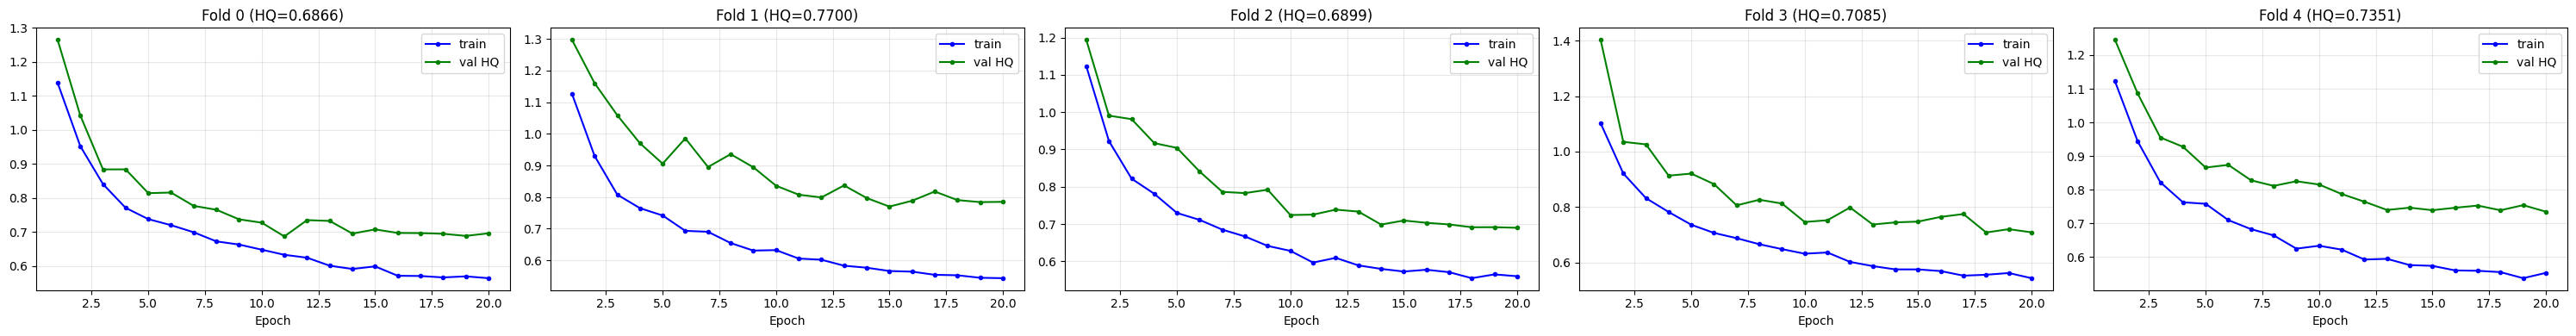


Fold 0
Epoch      Train Loss      Val Loss        Val Loss HQ    
-------------------------------------------------------
1          1.102419        1.329775        1.406303       
2          0.997974        1.066151        1.128938       
3          0.864901        0.962987        1.006609       
4          0.814028        0.900996        0.932925       
5          0.756601        0.835170        0.861109       
6          0.715255        0.775151        0.796536       
7          0.670994        0.787022        0.831669       
8          0.636066        0.762018        0.794519       
9          0.602785        0.775514        0.814847       
10         0.587568        0.735208        0.779206       
11         0.568233        0.717656        0.753817       
12         0.559348        0.717276        0.742877       
13         0.522984        0.747970        0.793851       
14         0.509242        0.681915        0.712471       
15         0.498709        0.647277        0.679761

In [17]:
n = len(all_histories)
if n == 0:
    print("No folds completed — skipping plots.")
else:
    fig, axes = plt.subplots(1, max(n, 1), figsize=(6*max(n, 1), 4))
    if n <= 1: axes = [axes]
    for ax, (fold, h) in zip(axes, all_histories.items()):
        ep = range(1, len(h["train_loss"])+1)
        ax.plot(ep, h["train_loss"], "b-o", ms=3, label="train")
        ax.plot(ep, h["val_loss_hq"], "g-o", ms=3, label="val HQ")
        ax.set_title(f"Fold {fold} (HQ={fold_results[fold]['hq']:.4f})")
        ax.set_xlabel("Epoch"); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()





import torch

for fold in CFG.run_folds:
    history = torch.load(str(MODELS_DIR / f"history_fold{fold}.pt"))
    
    print(f"\nFold {fold}")
    print(f"{'Epoch':<10} {'Train Loss':<15} {'Val Loss':<15} {'Val Loss HQ':<15}")
    print("-" * 55)
    for epoch, (train, val, val_hq) in enumerate(zip(
        history['train_loss'], history['val_loss'], history['val_loss_hq']), 1):
        print(f"{epoch:<10} {train:<15.6f} {val:<15.6f} {val_hq:<15.6f}")

    

In [18]:
# Model Structure
try:
    from torchinfo import summary as ti_summary
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torchinfo", "-q"])
    from torchinfo import summary as ti_summary

_m = SpectrogramModel(CFG)
ti_summary(_m,
    input_data=[torch.randn(1, CFG.num_bipolar_channels, CFG.eeg_samples), torch.randn(1, 32)],
    col_names=["output_size", "num_params"],
    col_width=22, depth=2, verbose=1)
del _m; gc.collect()


Freq: 0.39 Hz/bin, 52 bins (0-20.0 Hz)
STFT kernels created, time used = 0.0382 seconds
STFT kernels created, time used = 0.0108 seconds


Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Backbone: 208ch, image [832, T]
Layer (type:depth-idx)                             Output Shape           Param #
SpectrogramModel                                   [1, 6]                 --
├─STFT: 1-1                                        [16, 257, 79]          263,168
├─STFT: 1-2                                        [16, 257, 63]          263,168
├─EfficientNetFeatures: 1-3                        [1, 16, 416, 40]       --
│    └─Conv2dSame: 2-1                             [1, 32, 416, 40]       864
│    └─BatchNormAct2d: 2-2                         [1, 32, 416, 40]       64
│    └─Sequential: 2-3                             --                     8,390,478
├─GRU: 1-4                                         [1, 3, 512]            1,898,496
├─Linear: 1-5                                      [1, 3, 1]              513
├─Sequential: 1-6                                  [1, 32]                --
│    └─Linear: 2-4                                 [1, 64]                2,112
│    └─ReL

0

# Test Evaluation (confident_test.csv)

In [20]:
# Preprocess test EEGs if needed
# unique_test = confident_test_df.drop_duplicates(subset="eeg_id").reset_index(drop=True)
# print(f"Processing {len(unique_test)} test EEGs...")
# _ = joblib.Parallel(n_jobs=-1, backend="loky")(
#     joblib.delayed(preprocess_eeg)(i, unique_test, "test")
#     for i in tqdm(range(len(unique_test))))
# print("Done.")

# Build test loader
test_ds = HMSDataset(confident_test_df, mode="test")
test_loader = DataLoader(test_ds, batch_size=min(CFG.batch_size, len(confident_test_df)),
                          shuffle=False, num_workers=CFG.num_workers, pin_memory=True)

@torch.no_grad()
def predict(model, loader, device):
    model.eval()
    preds = []
    for eeg, stats in tqdm(loader, desc="Predicting"):
        with autocast(enabled=CFG.use_amp):
            p = model(eeg.to(device), stats.to(device))
        preds.append(p.cpu().numpy())
    return np.concatenate(preds, axis=0)

# Predict with each fold's best model
all_preds = []
for fold in CFG.run_folds:
    ckpt_path = MODELS_DIR / f"best_model_v14_fold{fold}.pt"
    if not ckpt_path.exists():
        print(f"Fold {fold}: checkpoint not found, skipping")
        continue
    model = SpectrogramModel(CFG).to(CFG.device)
    model.load_state_dict(torch.load(str(ckpt_path), map_location=CFG.device)["model_state_dict"])
    all_preds.append(predict(model, test_loader, CFG.device))
    print(f"Fold {fold}: done")
    del model; gc.collect(); torch.cuda.empty_cache()

preds = np.mean(all_preds, axis=0)
preds = preds / preds.sum(axis=1, keepdims=True)
print(f"\nEnsemble: {len(all_preds)} folds, shape={preds.shape}")

# Evaluate against confident_test labels if available
if "soft_labels" in confident_test_df.columns:
    targets = np.array(confident_test_df["soft_labels"].tolist(), dtype=np.float64)
    kl = (targets * np.log(targets.clip(1e-8) / preds.clip(1e-8))).sum(axis=1)
    print(f"\nTest KL Divergence:")
    print(f"  ALL: {kl.mean():.4f}")
    if "consensus" in confident_test_df.columns:
        consensus = confident_test_df["consensus"].values
        hq_mask = consensus >= 0.90
        if hq_mask.any():
            print(f"  HQ (>=90%): {kl[hq_mask].mean():.4f} ({hq_mask.sum()}/{len(hq_mask)})")
else:
    print("No test labels available for evaluation.")

Freq: 0.39 Hz/bin, 52 bins (0-20.0 Hz)
STFT kernels created, time used = 0.0097 seconds
STFT kernels created, time used = 0.0099 seconds


Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Backbone: 208ch, image [832, T]


Predicting:   0%|          | 0/414 [00:00<?, ?it/s]

/var/tmp/ipykernel_756840/2365999596.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CFG.use_amp):


...

Fold 3: done
Freq: 0.39 Hz/bin, 52 bins (0-20.0 Hz)
STFT kernels created, time used = 0.0115 seconds
STFT kernels created, time used = 0.0086 seconds


Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Backbone: 208ch, image [832, T]


Predicting:   0%|          | 0/414 [00:00<?, ?it/s]

Fold 4: done

Ensemble: 5 folds, shape=(6621, 6)

Test KL Divergence:
  ALL: 0.7569
  HQ (>=90%): 0.7637 (6064/6621)


# Submission

In [21]:
target_cols = [x.lower() + "_vote" for x in CFG.class_names]
pred_df = confident_test_df[["eeg_id"]].copy()
pred_df[target_cols] = preds.tolist()

sub_path = str(RESULTS_DIR / "submission_nnaudio_gru.csv")
pred_df.to_csv(sub_path, index=False)
print(f"Saved: {sub_path} ({len(pred_df)} rows)")
print(pred_df.head())

Saved: /home/littl/ECE247A_Final_Project/AL/AL_model/results/submission_nnaudio_gru.csv (6621 rows)
       eeg_id  seizure_vote  lpd_vote  gpd_vote  lrda_vote  grda_vote  \
0  4245882082      0.244311  0.006334  0.010538   0.037926   0.374654   
1  2857590162      0.070954  0.015344  0.016390   0.063670   0.351137   
2  2857590162      0.070954  0.015344  0.016390   0.063670   0.351137   
3  2857590162      0.070954  0.015344  0.016390   0.063670   0.351137   
4  3523834378      0.915477  0.012118  0.014481   0.007637   0.012024   

   other_vote  
0    0.326236  
1    0.482506  
2    0.482506  
3    0.482506  
4    0.038263  
